In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

** CELL 1 — Imports**

In [ ]:
import os, gc, pickle, time, warnings
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import OneCycleLR
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
 
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

**CELL 2 — Config**

In [2]:
CFG = dict(
    pkl_train    = '/kaggle/input/datasets/raghavender76/pklfiles/train_data.pkl',
    pkl_val      = '/kaggle/input/datasets/raghavender76/pklfiles/val_data.pkl',
    pkl_test     = '/kaggle/input/datasets/raghavender76/pklfiles/test_data.pkl',
    category_ids   = [1, 2, 7, 8, 9],
    category_names = ['Short Sleeve Top', 'Long Sleeve Top',
                      'Shorts', 'Trousers', 'Skirt'],
    img_size     = 224,
    batch_size   = 64,
    num_workers  = 0,
    pin_memory   = True,
    wd           = 1e-4,
)
NUM_CLASSES = len(CFG['category_names'])
print("Config ready. NUM_CLASSES =", NUM_CLASSES)

Config ready. NUM_CLASSES = 5


**CELL 3 — Load PKL Files**

In [3]:
def load_pkl(path):
    with open(path, 'rb') as f:
        data = pickle.load(f)
    print(f"Loaded {path}  →  type={type(data)}, len={len(data)}")
    return data
 
train_data = load_pkl(CFG['pkl_train'])
val_data   = load_pkl(CFG['pkl_val'])
test_data  = load_pkl(CFG['pkl_test'])
 
# train_data[0] = list of image paths
# train_data[1] = list of binary label vectors [0/1, 0/1, 0/1, 0/1, 0/1]
print("\nSample path :", train_data[0][0])
print("Sample label:", train_data[1][0])

Loaded /kaggle/input/datasets/raghavender76/pklfiles/train_data.pkl  →  type=<class 'tuple'>, len=2
Loaded /kaggle/input/datasets/raghavender76/pklfiles/val_data.pkl  →  type=<class 'tuple'>, len=2
Loaded /kaggle/input/datasets/raghavender76/pklfiles/test_data.pkl  →  type=<class 'tuple'>, len=2

Sample path : /kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_train/images/168202.jpg
Sample label: [1, 1, 0, 0, 0]


**Dataset Class**

In [4]:
class ApparelDataset(Dataset):
    def __init__(self, data, transform=None):
        self.transform = transform
        self.img_paths = data[0]
        self.labels    = data[1]
        print(f"Dataset built: {len(self.img_paths)} samples")
 
    def __len__(self):
        return len(self.img_paths)
 
    def __getitem__(self, idx):
        img   = Image.open(self.img_paths[idx]).convert('RGB')
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img, label

**Transforms**

In [5]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
 
train_tf = transforms.Compose([
    transforms.Resize((CFG['img_size'] + 32, CFG['img_size'] + 32)),
    transforms.RandomCrop(CFG['img_size']),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])
 
val_tf = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
print("Transforms ready.")

Transforms ready.


**Build Datasets**

In [6]:
train_ds = ApparelDataset(train_data, transform=train_tf)
val_ds   = ApparelDataset(val_data,   transform=val_tf)
test_ds  = ApparelDataset(test_data,  transform=val_tf)
 
del train_data, val_data, test_data
gc.collect()

Dataset built: 122547 samples
Dataset built: 23741 samples
Dataset built: 21627 samples


0

**Class Weights**

In [7]:
all_labels  = np.array(train_ds.labels, dtype=np.float32)
pos_counts  = all_labels.sum(axis=0)
neg_counts  = len(train_ds) - pos_counts
pos_weights = torch.tensor(neg_counts / (pos_counts + 1e-6),
                            dtype=torch.float32).to(DEVICE)
print("Pos weights:", pos_weights.cpu().numpy().round(2))

Pos weights: [1.04 1.62 2.98 3.04 3.71]


**Dataloaders**

In [10]:
train_loader = DataLoader(
    train_ds, batch_size=64, shuffle=True,
    num_workers=4, pin_memory=CFG['pin_memory'],
    drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=64, shuffle=False,
    num_workers=4, pin_memory=CFG['pin_memory'],
)
test_loader = DataLoader(
    test_ds, batch_size=64, shuffle=False,
    num_workers=CFG['num_workers'],
)
print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)}")

Batches — train: 1914 | val: 371


In [11]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
 
print("Criterion ready.")

Criterion ready.


**Helper Functions**

In [12]:
def find_best_thresholds(probs, targets, n_thresh=50):
    thresholds = np.linspace(0.2, 0.8, n_thresh)
    best_t = []
    for i in range(NUM_CLASSES):
        best_f1, best_th = 0, 0.5
        for t in thresholds:
            preds = (probs[:, i] >= t).astype(int)
            f1 = f1_score(targets[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_th = f1, t
        best_t.append(best_th)
    return np.array(best_t)
 
 
def validate(model, loader):
    model.eval()
    all_probs, all_targets = [], []
    val_loss_total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with autocast():
                logits = model(imgs)
                loss   = criterion(logits, labels)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_targets.append(labels.cpu().numpy())
            val_loss_total += loss.item()
    all_probs   = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)
    val_loss    = val_loss_total / len(loader)
    thresholds  = find_best_thresholds(all_probs, all_targets)
    preds       = (all_probs >= thresholds).astype(int)
    macro_f1    = f1_score(all_targets, preds, average='macro', zero_division=0)
    micro_f1    = f1_score(all_targets, preds, average='micro', zero_division=0)
    return val_loss, macro_f1, micro_f1, all_probs, all_targets, thresholds
 
 
def test_evaluate(model, loader, thresholds):
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with autocast():
                logits = model(imgs)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_targets.append(labels.cpu().numpy())
    return np.vstack(all_probs), np.vstack(all_targets)
 
 
print("Helper functions ready.")

Helper functions ready.


**Scratch Model**

In [14]:
class MobileNetV3Scratch(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        base = models.mobilenet_v3_large(weights=None)   # NO pretrained weights
        for p in base.parameters():
            p.requires_grad = True                        # train everything
        self.features   = base.features
        self.avgpool    = base.avgpool
        in_features     = base.classifier[0].in_features  # 960
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 512),
            nn.Hardswish(),
            nn.Dropout(p=dropout / 2),
            nn.Linear(512, num_classes),
        )
 
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)
 
scratch_model = MobileNetV3Scratch(NUM_CLASSES).to(DEVICE)
print("Scratch model ready — randomly initialized weights.")
print(f"Trainable params: {sum(p.numel() for p in scratch_model.parameters() if p.requires_grad):,}")

Scratch model ready — randomly initialized weights.
Trainable params: 3,466,549


**Scratch Training Loop**

In [15]:
SCRATCH_EPOCHS = 10
 
scratch_optimizer = torch.optim.AdamW(
    scratch_model.parameters(), lr=1e-3, weight_decay=CFG['wd']
)
scratch_scheduler = OneCycleLR(
    scratch_optimizer, max_lr=1e-3,
    epochs=SCRATCH_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.2, anneal_strategy='cos',
    div_factor=10, final_div_factor=100,
)
scratch_scaler  = GradScaler()
scratch_history = {'train_loss': [], 'val_loss': [], 'macro_f1': [], 'micro_f1': []}
best_scratch_f1          = 0.0
best_scratch_thresholds  = np.full(NUM_CLASSES, 0.5)
 
print("="*65)
print("MODE: SCRATCH (randomly initialized)")
print(f"{'Ep':>3} {'TrainLoss':>10} {'ValLoss':>9} {'MacroF1':>9} {'MicroF1':>9} {'Time':>7}")
print("="*65, flush=True)
 
for epoch in range(1, SCRATCH_EPOCHS + 1):
    scratch_model.train()
    total_loss = 0
    t0   = time.time()
    pbar = tqdm(train_loader,
                desc=f"Epoch {epoch}/{SCRATCH_EPOCHS} [Scratch]", leave=False)
 
    for imgs, labels in pbar:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        scratch_optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits = scratch_model(imgs)
            loss   = criterion(logits, labels)
        scratch_scaler.scale(loss).backward()
        scratch_scaler.unscale_(scratch_optimizer)
        torch.nn.utils.clip_grad_norm_(scratch_model.parameters(), 1.0)
        scratch_scaler.step(scratch_optimizer)
        scratch_scaler.update()
        scratch_scheduler.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
 
    train_loss = total_loss / len(train_loader)
    elapsed    = time.time() - t0
 
    val_loss, macro_f1, micro_f1, val_probs, val_targets, thresholds = \
        validate(scratch_model, val_loader)
 
    scratch_history['train_loss'].append(train_loss)
    scratch_history['val_loss'].append(val_loss)
    scratch_history['macro_f1'].append(macro_f1)
    scratch_history['micro_f1'].append(micro_f1)
 
    flag = ' ◀ best' if macro_f1 > best_scratch_f1 else ''
    print(f"{epoch:>3} {train_loss:>10.4f} {val_loss:>9.4f} "
          f"{macro_f1:>9.4f} {micro_f1:>9.4f} {elapsed:>6.1f}s{flag}", flush=True)
 
    if macro_f1 > best_scratch_f1:
        best_scratch_f1         = macro_f1
        best_scratch_thresholds = thresholds
        torch.save({
            'model_state': scratch_model.state_dict(),
            'thresholds':  best_scratch_thresholds,
            'macro_f1':    best_scratch_f1,
        }, '/kaggle/working/best_mobilenetv3_scratch.pth')
 
print(f"\nBest Scratch Val Macro F1: {best_scratch_f1:.4f}", flush=True)


MODE: SCRATCH (randomly initialized)
 Ep  TrainLoss   ValLoss   MacroF1   MicroF1    Time


Epoch 1/10 [Scratch]:   0%|          | 0/1914 [00:00<?, ?it/s]

  1     0.8962    1.0643    0.5351    0.5692  886.4s ◀ best


Epoch 2/10 [Scratch]:   0%|          | 0/1914 [00:00<?, ?it/s]

  2     0.7832    0.9063    0.5981    0.6249  705.8s ◀ best


...

  8     0.4677    0.4462    0.7911    0.8085  769.7s ◀ best


Epoch 9/10 [Scratch]:   0%|          | 0/1914 [00:00<?, ?it/s]

  9     0.4450    0.4456    0.7950    0.8133  714.6s ◀ best


Epoch 10/10 [Scratch]:   0%|          | 0/1914 [00:00<?, ?it/s]

 10     0.4346    0.4374    0.7979    0.8154  736.0s ◀ best

Best Scratch Val Macro F1: 0.7979


In [20]:
# Check if weights already cached
import os
cache_path = '/root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth'
if os.path.exists(cache_path):
    print("Weights already cached — internet not needed")
else:
    print("Weights NOT cached — enable internet in Kaggle settings")

Weights NOT cached — enable internet in Kaggle settings


**Transfer Model**

In [ ]:
# class MobileNetV3Transfer(nn.Module):
#     def __init__(self, num_classes, dropout=0.4):
#         super().__init__()
#         base = models.mobilenet_v3_large(
#             weights=models.MobileNet_V3_Large_Weights.DEFAULT)  # ImageNet weights
#         for p in base.parameters():
#             p.requires_grad = False                              # freeze backbone
#         self.features   = base.features
#         self.avgpool    = base.avgpool
#         in_features     = base.classifier[0].in_features        # 960
#         self.classifier = nn.Sequential(
#             nn.Dropout(p=dropout),
#             nn.Linear(in_features, 512),
#             nn.Hardswish(),
#             nn.Dropout(p=dropout / 2),
#             nn.Linear(512, num_classes),
#         )
 
#     def forward(self, x):
#         x = self.features(x)
#         x = self.avgpool(x)
#         x = torch.flatten(x, 1)
#         return self.classifier(x)
 
#     def unfreeze_last_blocks(self, n=3):
#         blocks = list(self.features.children())
#         for block in blocks[-n:]:
#             for p in block.parameters():
#                 p.requires_grad = True
#         total = sum(p.numel() for p in self.parameters() if p.requires_grad)
#         print(f"Unfrozen last {n} blocks. Trainable params: {total:,}", flush=True)
 
# transfer_model = MobileNetV3Transfer(NUM_CLASSES).to(DEVICE)
# print("Transfer model ready — ImageNet pretrained weights loaded, backbone frozen.")
# print(f"Trainable params (classifier only): "
#       f"{sum(p.numel() for p in transfer_model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 130MB/s] 


Transfer model ready — ImageNet pretrained weights loaded, backbone frozen.
Trainable params (classifier only): 494,597


**Transfer Training Loop**

In [ ]:
# TRANSFER_EPOCHS = 10
# UNFREEZE_EPOCH  = 3
 
# transfer_optimizer = torch.optim.AdamW(
#     filter(lambda p: p.requires_grad, transfer_model.parameters()),
#     lr=3e-4, weight_decay=CFG['wd']
# )
# transfer_scheduler = OneCycleLR(
#     transfer_optimizer, max_lr=3e-4,
#     epochs=TRANSFER_EPOCHS,
#     steps_per_epoch=len(train_loader),
#     pct_start=0.2, anneal_strategy='cos',
#     div_factor=10, final_div_factor=100,
# )
# transfer_scaler  = GradScaler()
# transfer_history = {'train_loss': [], 'val_loss': [], 'macro_f1': [], 'micro_f1': []}
# best_transfer_f1          = 0.0
# best_transfer_thresholds  = np.full(NUM_CLASSES, 0.5)
 
# print("="*65)
# print("MODE: TRANSFER LEARNING (ImageNet pretrained)")
# print(f"{'Ep':>3} {'TrainLoss':>10} {'ValLoss':>9} {'MacroF1':>9} {'MicroF1':>9} {'Time':>7}")
# print("="*65, flush=True)
 
# for epoch in range(1, TRANSFER_EPOCHS + 1):
 
#     # Unfreeze last 3 blocks after warm-up epochs
#     if epoch == UNFREEZE_EPOCH:
#         transfer_model.unfreeze_last_blocks(n=3)
#         transfer_optimizer = torch.optim.AdamW([
#             {'params': filter(lambda p: p.requires_grad,
#                               transfer_model.features.parameters()),
#              'lr': 5e-5},                      # low lr for backbone
#             {'params': transfer_model.classifier.parameters(),
#              'lr': 3e-4},                      # higher lr for classifier
#         ], weight_decay=CFG['wd'])
#         transfer_scheduler = OneCycleLR(
#             transfer_optimizer,
#             max_lr=[5e-5, 3e-4],
#             epochs=TRANSFER_EPOCHS - epoch + 1,
#             steps_per_epoch=len(train_loader),
#             pct_start=0.1, anneal_strategy='cos',
#         )
 
#     transfer_model.train()
#     total_loss = 0
#     t0   = time.time()
#     pbar = tqdm(train_loader,
#                 desc=f"Epoch {epoch}/{TRANSFER_EPOCHS} [Transfer]", leave=False)
 
#     for imgs, labels in pbar:
#         imgs   = imgs.to(DEVICE, non_blocking=True)
#         labels = labels.to(DEVICE, non_blocking=True)
#         transfer_optimizer.zero_grad(set_to_none=True)
#         with autocast():
#             logits = transfer_model(imgs)
#             loss   = criterion(logits, labels)
#         transfer_scaler.scale(loss).backward()
#         transfer_scaler.unscale_(transfer_optimizer)
#         torch.nn.utils.clip_grad_norm_(transfer_model.parameters(), 1.0)
#         transfer_scaler.step(transfer_optimizer)
#         transfer_scaler.update()
#         transfer_scheduler.step()
#         total_loss += loss.item()
#         pbar.set_postfix({'loss': f'{loss.item():.4f}'})
 
#     train_loss = total_loss / len(train_loader)
#     elapsed    = time.time() - t0
 
#     val_loss, macro_f1, micro_f1, val_probs, val_targets, thresholds = \
#         validate(transfer_model, val_loader)
 
#     transfer_history['train_loss'].append(train_loss)
#     transfer_history['val_loss'].append(val_loss)
#     transfer_history['macro_f1'].append(macro_f1)
#     transfer_history['micro_f1'].append(micro_f1)
 
#     flag = ' ◀ best' if macro_f1 > best_transfer_f1 else ''
#     print(f"{epoch:>3} {train_loss:>10.4f} {val_loss:>9.4f} "
#           f"{macro_f1:>9.4f} {micro_f1:>9.4f} {elapsed:>6.1f}s{flag}", flush=True)
 
#     if macro_f1 > best_transfer_f1:
#         best_transfer_f1         = macro_f1
#         best_transfer_thresholds = thresholds
#         torch.save({
#             'model_state': transfer_model.state_dict(),
#             'thresholds':  best_transfer_thresholds,
#             'macro_f1':    best_transfer_f1,
#         }, '/kaggle/working/best_mobilenetv3_transfer.pth')
 
# print(f"\nBest Transfer Val Macro F1: {best_transfer_f1:.4f}", flush=True)

MODE: TRANSFER LEARNING (ImageNet pretrained)
 Ep  TrainLoss   ValLoss   MacroF1   MicroF1    Time


Epoch 1/10 [Transfer]:   0%|          | 0/1914 [00:00<?, ?it/s]

  1     0.8372    0.7575    0.6159    0.6459  697.0s ◀ best


Epoch 2/10 [Transfer]:   0%|          | 0/1914 [00:00<?, ?it/s]

  2     0.7847    0.7343    0.6272    0.6576  744.1s ◀ best
Unfrozen last 3 blocks. Trainable params: 2,244,837


...

  8     0.4733    0.4595    0.7801    0.7991  778.2s ◀ best


Epoch 9/10 [Transfer]:   0%|          | 0/1914 [00:00<?, ?it/s]

  9     0.4650    0.4592    0.7814    0.8003  764.0s ◀ best


Epoch 10/10 [Transfer]:   0%|          | 0/1914 [00:00<?, ?it/s]

 10     0.4646    0.4597    0.7815    0.8001  772.4s ◀ best

Best Transfer Val Macro F1: 0.7815


**Final Test Evaluation + Comparison**

In [ ]:
# # Load best scratch
# ckpt_s = torch.load('/kaggle/working/best_mobilenetv3_scratch.pth',
#                     weights_only=False)
# scratch_model.load_state_dict(ckpt_s['model_state'])
# s_probs, s_targets = test_evaluate(scratch_model, test_loader,
#                                    ckpt_s['thresholds'])
# s_preds = (s_probs >= ckpt_s['thresholds']).astype(int)
 
# # Load best transfer
# ckpt_t = torch.load('/kaggle/working/best_mobilenetv3_transfer.pth',
#                     weights_only=False)
# transfer_model.load_state_dict(ckpt_t['model_state'])
# t_probs, t_targets = test_evaluate(transfer_model, test_loader,
#                                    ckpt_t['thresholds'])
# t_preds = (t_probs >= ckpt_t['thresholds']).astype(int)
 
# # Per-class report for both
# for mode, probs, targets, preds in [
#     ('SCRATCH',  s_probs, s_targets, s_preds),
#     ('TRANSFER', t_probs, t_targets, t_preds),
# ]:
#     print(f"\n{'='*57}")
#     print(f"PER-CLASS EVALUATION REPORT: MOBILENETV3_{mode}")
#     print(f"{'='*57}")
#     for i, name in enumerate(CFG['category_names']):
#         prec = precision_score(targets[:, i], preds[:, i], zero_division=0)
#         rec  = recall_score(targets[:, i],    preds[:, i], zero_division=0)
#         f1   = f1_score(targets[:, i],        preds[:, i], zero_division=0)
#         try:    auc = roc_auc_score(targets[:, i], probs[:, i])
#         except: auc = float('nan')
#         print(f"\nCategory: {name}")
#         print(f"  Precision: {prec:.4f}")
#         print(f"  Recall:    {rec:.4f}")
#         print(f"  F1-Score:  {f1:.4f}")
#         print(f"  AUC:       {auc:.4f}")
#     macro = f1_score(targets, preds, average='macro', zero_division=0)
#     micro = f1_score(targets, preds, average='micro', zero_division=0)
#     print(f"\n{'─'*57}")
#     print(f"MobileNetV3_{mode} Macro-Averaged F1-Score: {macro:.4f}")
#     print(f"MobileNetV3_{mode} Micro-Averaged F1-Score: {micro:.4f}")
#     print(f"{'─'*57}")
 


PER-CLASS EVALUATION REPORT: MOBILENETV3_SCRATCH

Category: Short Sleeve Top
  Precision: 0.7865
  Recall:    0.8594
  F1-Score:  0.8213
  AUC:       0.9066

Category: Long Sleeve Top
  Precision: 0.9030
  Recall:    0.8884
  F1-Score:  0.8957
  AUC:       0.9767

Category: Shorts
  Precision: 0.8703
  Recall:    0.8083
  F1-Score:  0.8382
  AUC:       0.9646

Category: Trousers
  Precision: 0.6462
  Recall:    0.7621
  F1-Score:  0.6994
  AUC:       0.9041

Category: Skirt
  Precision: 0.6695
  Recall:    0.8150
  F1-Score:  0.7351
  AUC:       0.9370

─────────────────────────────────────────────────────────
MobileNetV3_SCRATCH Macro-Averaged F1-Score: 0.7979
MobileNetV3_SCRATCH Micro-Averaged F1-Score: 0.8084
─────────────────────────────────────────────────────────

PER-CLASS EVALUATION REPORT: MOBILENETV3_TRANSFER

Category: Short Sleeve Top
  Precision: 0.7530
  Recall:    0.8662
  F1-Score:  0.8056
  AUC:       0.8862

Category: Long Sleeve Top
  Precision: 0.8945
  Recall:    

**ROC Curves,Training Curves,Scratch vs Transfer Comparison Bar Chart**

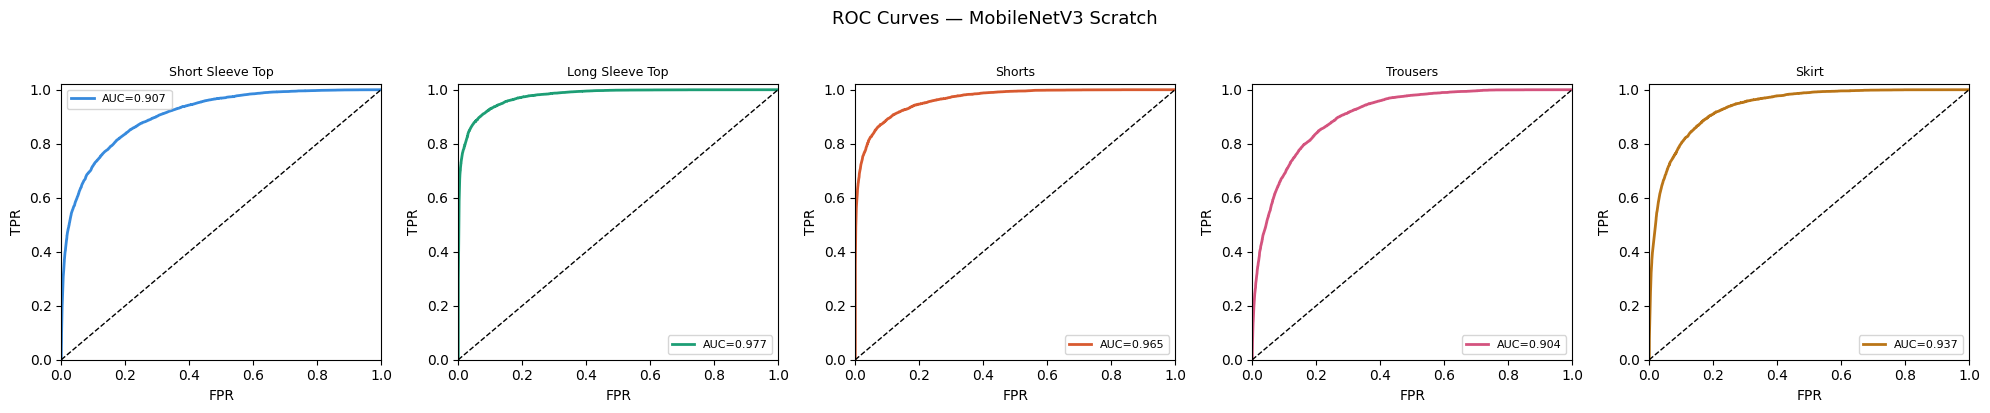

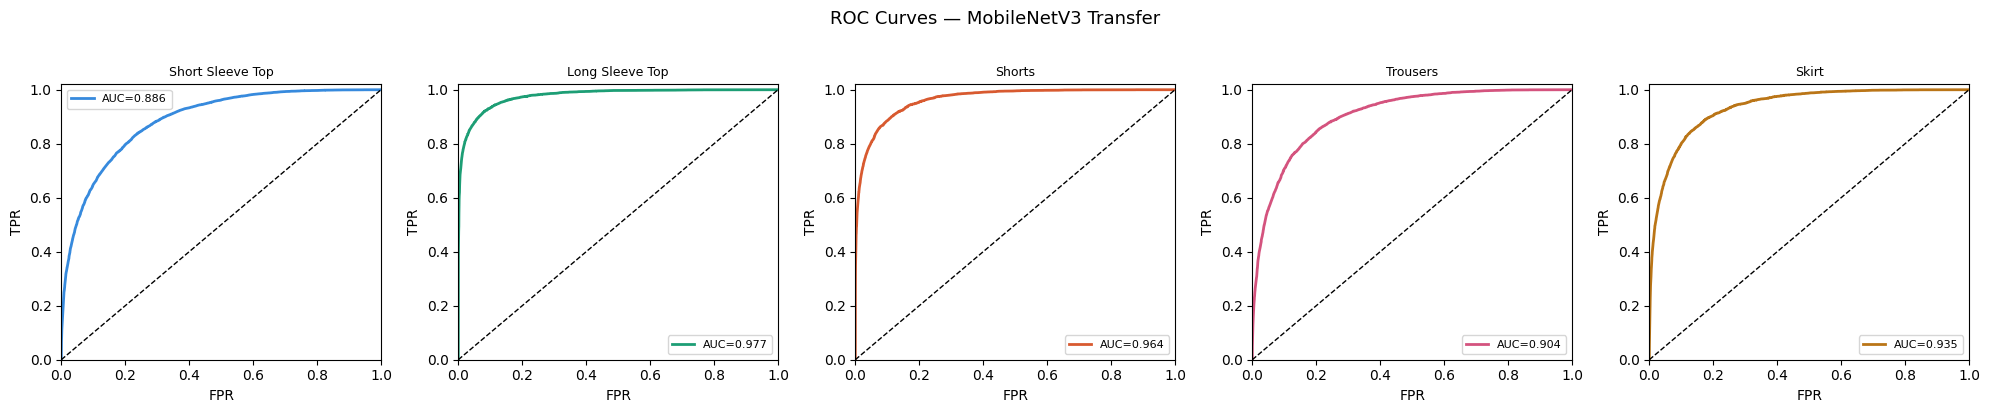

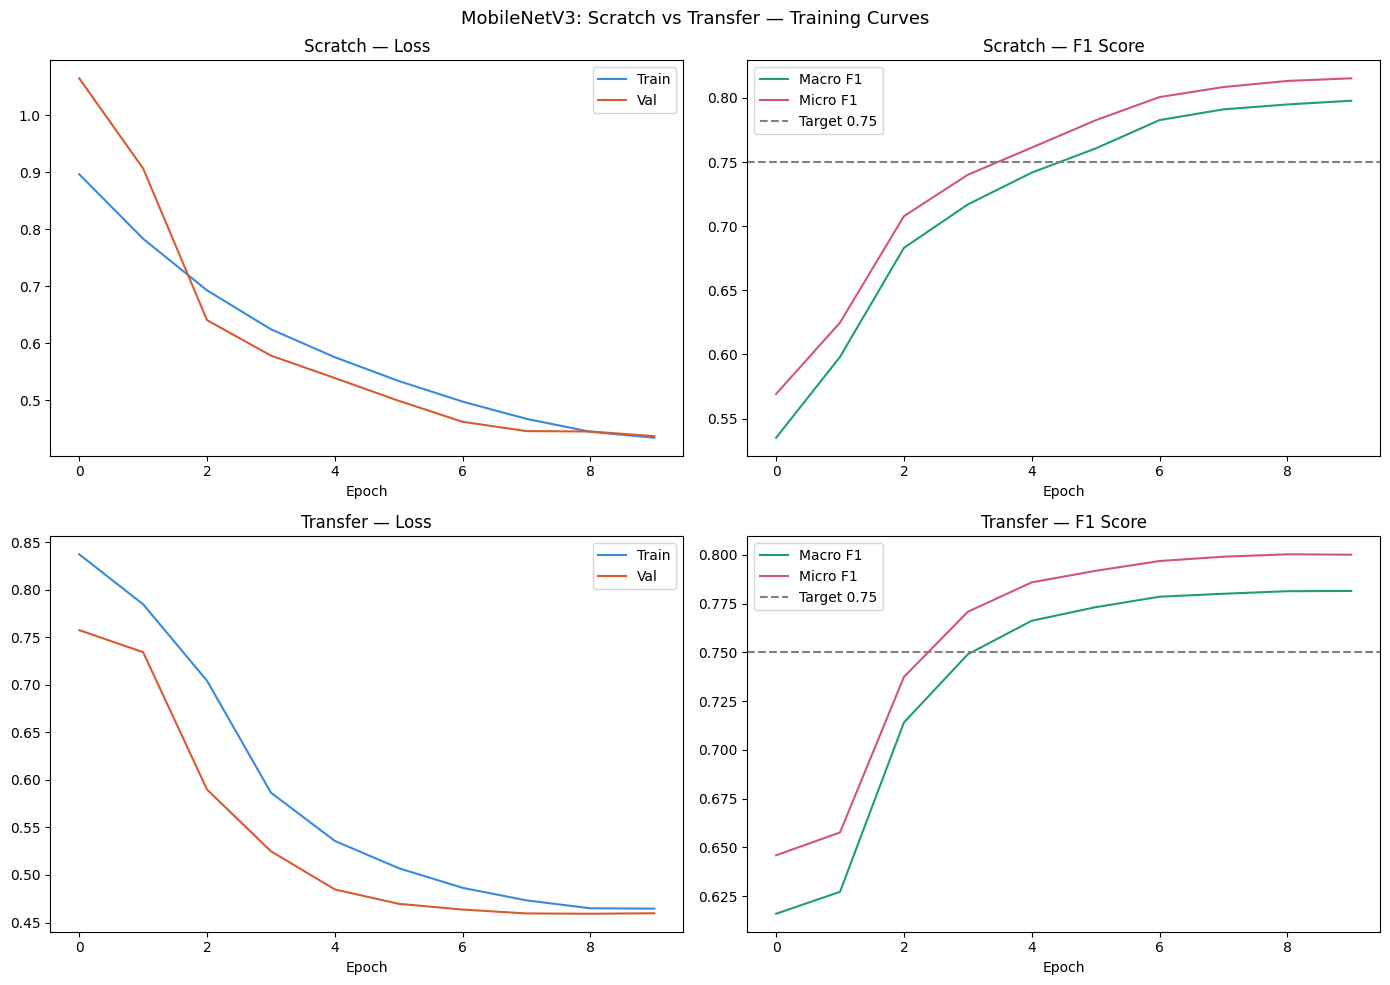

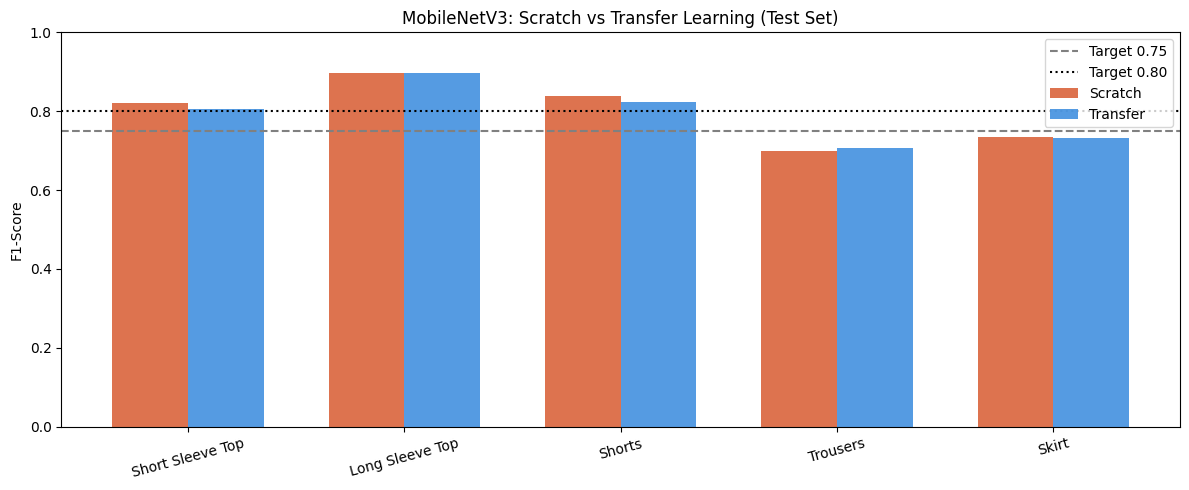

In [ ]:
# colors = ['#378ADD', '#1D9E75', '#D85A30', '#D4537E', '#BA7517']
 
# for mode, probs, targets in [
#     ('Scratch',  s_probs, s_targets),
#     ('Transfer', t_probs, t_targets),
# ]:
#     fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))
#     for i, (name, ax, color) in enumerate(
#             zip(CFG['category_names'], axes, colors)):
#         try:
#             fpr, tpr, _ = roc_curve(targets[:, i], probs[:, i])
#             auc = roc_auc_score(targets[:, i], probs[:, i])
#             ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC={auc:.3f}')
#         except:
#             pass
#         ax.plot([0, 1], [0, 1], 'k--', lw=1)
#         ax.set_title(name, fontsize=9)
#         ax.set_xlabel('FPR')
#         ax.set_ylabel('TPR')
#         ax.legend(fontsize=8)
#         ax.set_xlim([0, 1])
#         ax.set_ylim([0, 1.02])
#     plt.suptitle(f'ROC Curves — MobileNetV3 {mode}', fontsize=13, y=1.02)
#     plt.tight_layout()
#     plt.savefig(f'/kaggle/working/roc_mobilenetv3_{mode.lower()}.png',
#                 dpi=150, bbox_inches='tight')
#     plt.show()
 
 
# # ============================================================
# # CELL 17 — Training Curves
# # ============================================================
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
# axes[0, 0].plot(scratch_history['train_loss'],  label='Train', color='#378ADD')
# axes[0, 0].plot(scratch_history['val_loss'],    label='Val',   color='#D85A30')
# axes[0, 0].set_title('Scratch — Loss')
# axes[0, 0].set_xlabel('Epoch'); axes[0, 0].legend()
 
# axes[0, 1].plot(scratch_history['macro_f1'],  label='Macro F1', color='#1D9E75')
# axes[0, 1].plot(scratch_history['micro_f1'],  label='Micro F1', color='#D4537E')
# axes[0, 1].axhline(0.75, color='gray', linestyle='--', label='Target 0.75')
# axes[0, 1].set_title('Scratch — F1 Score')
# axes[0, 1].set_xlabel('Epoch'); axes[0, 1].legend()
 
# axes[1, 0].plot(transfer_history['train_loss'], label='Train', color='#378ADD')
# axes[1, 0].plot(transfer_history['val_loss'],   label='Val',   color='#D85A30')
# axes[1, 0].set_title('Transfer — Loss')
# axes[1, 0].set_xlabel('Epoch'); axes[1, 0].legend()
 
# axes[1, 1].plot(transfer_history['macro_f1'], label='Macro F1', color='#1D9E75')
# axes[1, 1].plot(transfer_history['micro_f1'], label='Micro F1', color='#D4537E')
# axes[1, 1].axhline(0.75, color='gray', linestyle='--', label='Target 0.75')
# axes[1, 1].set_title('Transfer — F1 Score')
# axes[1, 1].set_xlabel('Epoch'); axes[1, 1].legend()
 
# plt.suptitle('MobileNetV3: Scratch vs Transfer — Training Curves', fontsize=13)
# plt.tight_layout()
# plt.savefig('/kaggle/working/training_curves_mobilenetv3.png',
#             dpi=150, bbox_inches='tight')
# plt.show()
 
 
# # ============================================================
# # CELL 18 — Scratch vs Transfer Comparison Bar Chart
# # ============================================================
# f1_scratch  = [f1_score(s_targets[:, i], s_preds[:, i], zero_division=0)
#                for i in range(NUM_CLASSES)]
# f1_transfer = [f1_score(t_targets[:, i], t_preds[:, i], zero_division=0)
#                for i in range(NUM_CLASSES)]
 
# x     = np.arange(NUM_CLASSES)
# width = 0.35
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.bar(x - width/2, f1_scratch,  width, label='Scratch',  color='#D85A30', alpha=0.85)
# ax.bar(x + width/2, f1_transfer, width, label='Transfer', color='#378ADD', alpha=0.85)
# ax.axhline(0.75, color='gray', linestyle='--', label='Target 0.75')
# ax.axhline(0.80, color='black', linestyle=':', label='Target 0.80')
# ax.set_xticks(x)
# ax.set_xticklabels(CFG['category_names'], rotation=15)
# ax.set_ylabel('F1-Score')
# ax.set_ylim(0, 1)
# ax.set_title('MobileNetV3: Scratch vs Transfer Learning (Test Set)')
# ax.legend()
# plt.tight_layout()
# plt.savefig('/kaggle/working/scratch_vs_transfer_mobilenetv3.png',
#             dpi=150, bbox_inches='tight')
# plt.show()

In [25]:
from IPython.display import FileLink, display
import zipfile
 
zip_path = '/kaggle/working/mobilenetv3_models.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('/kaggle/working/best_mobilenetv3_scratch.pth',
             'best_mobilenetv3_scratch.pth')
    zf.write('/kaggle/working/best_mobilenetv3_transfer.pth',
             'best_mobilenetv3_transfer.pth')
 
size = os.path.getsize(zip_path) / (1024 * 1024)
print(f"Zip ready: {size:.1f} MB")
display(FileLink(zip_path))

Zip ready: 24.8 MB


/kaggle/working/mobilenetv3_models.zip

In [ ]:
# changed transfer learning

In [ ]:
# class MobileNetV3Transfer(nn.Module):
#     def __init__(self, num_classes, dropout=0.4):
#         super().__init__()

#         base = models.mobilenet_v3_large(
#             weights=models.MobileNet_V3_Large_Weights.DEFAULT
#         )

#         self.features = base.features
#         self.avgpool = base.avgpool

#         in_features = base.classifier[0].in_features  # 960

#         self.classifier = nn.Sequential(
#             nn.Dropout(p=dropout),
#             nn.Linear(in_features, 512),
#             nn.Hardswish(),
#             nn.Dropout(p=dropout / 2),
#             nn.Linear(512, num_classes),
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.avgpool(x)
#         x = torch.flatten(x, 1)
#         return self.classifier(x)


# transfer_model = MobileNetV3Transfer(NUM_CLASSES).to(DEVICE)
# print("Transfer model ready — ImageNet pretrained weights loaded.")

In [ ]:
# TRANSFER_EPOCHS = 10
# FREEZE_EPOCHS   = 0   # Stage 1
# UNFREEZE_EPOCH  = FREEZE_EPOCHS + 1

# # =========================
# # 🔹 Stage 1: Freeze backbone
# # =========================
# for p in transfer_model.features.parameters():
#     p.requires_grad = False

# for p in transfer_model.classifier.parameters():
#     p.requires_grad = True

# print(f"Stage 1: Training classifier only")
# print(f"Trainable params: {sum(p.numel() for p in transfer_model.parameters() if p.requires_grad):,}")

# optimizer = torch.optim.AdamW(
#     transfer_model.classifier.parameters(),
#     lr=3e-4,
#     weight_decay=CFG['wd']
# )

# scheduler = OneCycleLR(
#     optimizer,
#     max_lr=3e-4,
#     epochs=TRANSFER_EPOCHS,
#     steps_per_epoch=len(train_loader),
# )

# scaler = GradScaler()

# best_transfer_f1 = 0.0

# print("="*65)
# print("MODE: TRANSFER LEARNING (2-STAGE)")
# print("="*65)

# # =========================
# # 🔁 Training Loop
# # =========================
# for epoch in range(1, TRANSFER_EPOCHS + 1):

#     # =========================
#     # 🔥 Stage 2: Unfreeze ALL layers
#     # =========================
#     if epoch == UNFREEZE_EPOCH:
#         print("\n🔥 Unfreezing entire backbone...\n")

#         for p in transfer_model.features.parameters():
#             p.requires_grad = True

#         optimizer = torch.optim.AdamW([
#             {'params': transfer_model.features.parameters(), 'lr': 1e-5},  # low LR
#             {'params': transfer_model.classifier.parameters(), 'lr': 3e-4}
#         ], weight_decay=CFG['wd'])

#         scheduler = OneCycleLR(
#             optimizer,
#             max_lr=[1e-5, 3e-4],
#             epochs=TRANSFER_EPOCHS - epoch + 1,
#             steps_per_epoch=len(train_loader),
#         )

#     transfer_model.train()
#     total_loss = 0

#     for imgs, labels in tqdm(train_loader, leave=False):
#         imgs = imgs.to(DEVICE)
#         labels = labels.to(DEVICE)

#         optimizer.zero_grad(set_to_none=True)

#         with autocast():
#             logits = transfer_model(imgs)
#             loss = criterion(logits, labels)

#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()
#         scheduler.step()

#         total_loss += loss.item()

#     train_loss = total_loss / len(train_loader)

#     # =========================
#     # 🔍 Validation
#     # =========================
#     val_loss, macro_f1, micro_f1, val_probs, val_targets, thresholds = \
#         validate(transfer_model, val_loader)

#     print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val F1: {macro_f1:.4f}")

#     # =========================
#     # 💾 Save best model
#     # =========================
#     if macro_f1 > best_transfer_f1:
#         best_transfer_f1 = macro_f1

#         torch.save({
#             'model_state': transfer_model.state_dict(),
#             'macro_f1': best_transfer_f1,
#         }, '/kaggle/working/best_transfer.pth')

# print(f"\n✅ Best Transfer F1: {best_transfer_f1:.4f}")